Fashion Forward is a new AI-based e-commerce clothing retailer.
They want to use image classification to automatically categorize new product listings, making it easier for customers to find what they're looking for. It will also assist in inventory management by quickly sorting items.

As a data scientist tasked with implementing a garment classifier, your primary objective is to develop a machine learning model capable of accurately categorizing images of clothing items into distinct garment types such as shirts, trousers, shoes, etc.

In [106]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchmetrics import Accuracy, Precision, Recall

In [107]:
# Load datasets
from torchvision import datasets
import torchvision.transforms as transforms

train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
test_data = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

Train Sample Size: 60000
Test Sample Size: 10000
Train Sample Image Shape: torch.Size([1, 28, 28])
Train Sample Label: 9
Test Sample Image Shape: torch.Size([1, 28, 28])
Test Sample Label: 9


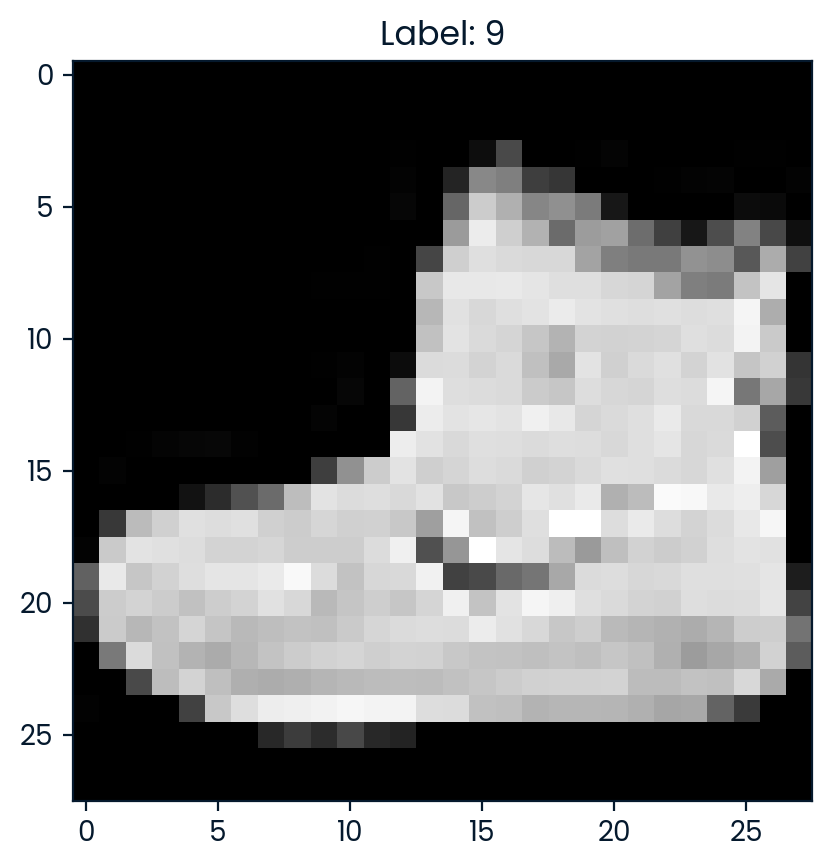

In [ ]:
#Get Image Shape in Train and Test Datasets
import matplotlib.pyplot as plt

print ("Train Sample Size:", len(train_data))
print ("Test Sample Size:", len(test_data))

train_image_sample, train_label_sample = train_data[0]
print ("Train Sample Image Shape:", train_image_sample.shape)
print ("Train Sample Label:", train_label_sample)

test_image_sample, test_label_sample = test_data[0]
print ("Test Sample Image Shape:", test_image_sample.shape)
print ("Test Sample Label:", test_label_sample)

#Display Sample Image
train_image_sample = train_image_sample.permute(1, 2, 0)
plt.imshow(train_image_sample.squeeze(), cmap='gray')
plt.title(f"Label: {train_label_sample}")
plt.show()

In [109]:

if hasattr(train_data, "targets") and hasattr(train_data, "classes"):
    labels = torch.tensor(train_data.targets)
    output_labels_values, output_labels_count = torch.unique(labels, return_counts=True)
    output_labels = train_data.classes

    for label, val, count in zip(output_labels, output_labels_values, output_labels_count):
        print (f"Label: {label}, Label Value: {val} Count: {count}")
    
print (f"\nDistinct Output Label Count: {len(output_labels)}")

Label: T-shirt/top, Label Value: 0 Count: 6000
Label: Trouser, Label Value: 1 Count: 6000
Label: Pullover, Label Value: 2 Count: 6000
Label: Dress, Label Value: 3 Count: 6000
Label: Coat, Label Value: 4 Count: 6000
Label: Sandal, Label Value: 5 Count: 6000
Label: Shirt, Label Value: 6 Count: 6000
Label: Sneaker, Label Value: 7 Count: 6000
Label: Bag, Label Value: 8 Count: 6000
Label: Ankle boot, Label Value: 9 Count: 6000

Distinct Output Label Count: 10


In [110]:
#Define NN Model Structure
#Input Image is of shape torch.Size([1, 28, 28])
class ClothingClassifier(nn.Module):
    def __init__(self, input_channels: int, output_channels: int, image_size: int, output_label_count: int):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(input_channels, output_channels, kernel_size = 3, padding = 1)
            , nn.ELU()
            , nn.MaxPool2d(kernel_size = 2)
            , nn.Conv2d(output_channels, output_channels*2, kernel_size = 3, padding = 1)
            , nn.ELU()
            , nn.MaxPool2d(kernel_size = 2)
            , nn.Flatten()
        )

        self.classifier = nn.Linear((output_channels*2) * (image_size//4) * (image_size//4), output_label_count)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

In [111]:
#Initialize Variable
input_channels = train_data[0][0].shape[0]
output_channels = 32
image_size =  train_data[0][0].shape[1]
output_label_count = len(output_labels)

model = ClothingClassifier(input_channels, output_channels, image_size, output_label_count)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

train_dataloader = DataLoader(train_data, batch_size=5, shuffle=True)
train_epoch_count = 2

test_dataloader = DataLoader(test_data, batch_size=5, shuffle=False)
test_accuracy = Accuracy(task = "multiclass", num_classes=output_label_count)
test_recall = Recall(task = "multiclass", num_classes=output_label_count, average=None)
test_precision = Precision(task = "multiclass", num_classes=output_label_count, average=None)

predictions = []

In [ ]:
#Train Model
model.train()

for epoch in range(train_epoch_count):
    running_loss = 0
    for images, labels in train_dataloader:
        optimizer.zero_grad()
        preds = model(images)
        loss = criterion(preds,labels)
        loss.backward()
        optimizer.step()
        running_loss+=loss.item()

    print(f"Epoch: {epoch}, Loss: {running_loss}")

Epoch: 0, Loss: 4613.700783701926
Epoch: 1, Loss: 3346.6451714468544


In [ ]:
#Get Validation Stats
model.eval()

with torch.no_grad():
    for images, labels in test_dataloader:
        preds = model(images)
        _, preds = torch.max(preds, 1)
        predictions+=preds.tolist()
        test_accuracy(preds, labels)
        test_recall(preds, labels)
        test_precision(preds, labels)

In [ ]:
#Compute Final Metrics
# accuracy = test_accuracy.compute().item()
recall = test_recall.compute().tolist()
precision = test_precision.compute().tolist()
            
print (f"Test Accuracy: {accuracy}")
print (f"Test Recall: {recall}")
print (f"Test Precision: {precision}")

Test Accuracy: 0.8837000131607056
Test Recall: [0.8090000152587891, 0.9850000143051147, 0.7269999980926514, 0.9300000071525574, 0.9399999976158142, 0.9769999980926514, 0.5860000252723694, 0.9279999732971191, 0.9779999852180481, 0.9769999980926514]
Test Precision: [0.8588110208511353, 0.9762140512466431, 0.8748495578765869, 0.847766637802124, 0.6772334575653076, 0.9682854413986206, 0.8027397394180298, 0.971727728843689, 0.9799599051475525, 0.9385206699371338]


In [ ]:
#See Recall and Precision by Output Label Category
for cat, r, p in zip(output_labels, recall, precision):
    print(f"{cat} - Recall:{r}, Precision:{p}")

T-shirt/top - Recall:0.8090000152587891, Precision:0.8588110208511353
Trouser - Recall:0.9850000143051147, Precision:0.9762140512466431
Pullover - Recall:0.7269999980926514, Precision:0.8748495578765869
Dress - Recall:0.9300000071525574, Precision:0.847766637802124
Coat - Recall:0.9399999976158142, Precision:0.6772334575653076
Sandal - Recall:0.9769999980926514, Precision:0.9682854413986206
Shirt - Recall:0.5860000252723694, Precision:0.8027397394180298
Sneaker - Recall:0.9279999732971191, Precision:0.971727728843689
Bag - Recall:0.9779999852180481, Precision:0.9799599051475525
Ankle boot - Recall:0.9769999980926514, Precision:0.9385206699371338
